# 16 — Fraud Final Evaluation

## Objectif

Cette étape réalise l'évaluation finale du modèle de détection
de fraude sur l'année 1996.

La configuration a été entièrement sélectionnée à partir de :

- 1994 pour l'entraînement et le tuning interne ;
- 1995 pour la validation temporelle et la sélection du seuil.

Configuration verrouillée :

- Random Forest ;
- calibration isotonic ;
- seuil technique = 0.085858.

Les performances de 1996 ne seront pas utilisées pour modifier
les hyperparamètres, la calibration ou le seuil.

Remarque méthodologique :
la prévalence globale de 1996 avait déjà été inspectée descriptivement,
mais aucune prédiction sur 1996 n'a participé à la sélection du modèle.

In [1]:
import pandas as pd
import numpy as np

import json
import time
import joblib

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import StratifiedKFold

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:
    if path.exists():
        PROCESSED_DIR = path
        break

if PROCESSED_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = PROCESSED_DIR.parent
METADATA_DIR = DATA_DIR / "metadata"

ARTIFACTS_DIR = (
    DATA_DIR.parent
    / "artifacts"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR = (
    DATA_DIR.parent
    / "reports"
    / "models"
    / "fraud"
    / "final"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


fraud = pd.read_csv(
    PROCESSED_DIR
    / "fraud_modeling_base.csv"
)

print(
    "Fraud dataset :",
    fraud.shape
)

Fraud dataset : (15420, 25)


In [3]:
with open(
    METADATA_DIR / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:

    feature_manifest = json.load(f)


with open(
    METADATA_DIR / "fraud_candidate.json",
    "r",
    encoding="utf-8"
) as f:

    candidate_config = json.load(f)


fraud_config = (
    feature_manifest["fraud"]
)


print(
    json.dumps(
        candidate_config,
        indent=4
    )
)

{
    "task": "fraud_classification",
    "model": "random_forest",
    "best_parameters": {
        "n_estimators": 800,
        "min_samples_split": 5,
        "min_samples_leaf": 10,
        "max_features": "log2",
        "max_depth": 16,
        "class_weight": null
    },
    "calibration": "isotonic",
    "validation_pr_auc": 0.09038410368422278,
    "validation_roc_auc": 0.6710019862955114,
    "validation_brier": 0.05381599102173139,
    "technical_threshold": 0.08585764735167348,
    "threshold_policy": "maximum_f1_on_1995_validation",
    "training_year": 1994,
    "validation_year": 1995,
    "test_year": 1996,
    "test_used": false
}


In [4]:
assert candidate_config["model"] == "random_forest"
assert candidate_config["calibration"] == "isotonic"
assert candidate_config["test_used"] is False

print(
    "✅ Configuration verrouillée chargée."
)

✅ Configuration verrouillée chargée.


In [5]:
continuous_features = (
    fraud_config[
        "continuous_features"
    ]
)

ordinal_features = (
    fraud_config[
        "ordinal_features"
    ]
)

categorical_features = (
    fraud_config[
        "categorical_features"
    ]
)

features = (
    continuous_features
    +
    ordinal_features
    +
    categorical_features
)

In [6]:
forbidden_features = {
    "PolicyNumber",
    "FraudFound_P",
    "Year",
    "RepNumber",
    "PolicyType",
    "Fault",
    "PoliceReportFiled",
    "WitnessPresent",
    "NumberOfSuppliments",
    "Days_Policy_Accident",
    "Days_Policy_Claim",
    "AddressChange_Claim"
}

unexpected = (
    forbidden_features
    .intersection(
        set(features)
    )
)

assert len(unexpected) == 0

print(
    "✅ Leakage check : OK"
)

✅ Leakage check : OK


In [7]:
train_1994 = (
    fraud[
        fraud["Year"] == 1994
    ]
    .copy()
)

validation_1995 = (
    fraud[
        fraud["Year"] == 1995
    ]
    .copy()
)

test_1996 = (
    fraud[
        fraud["Year"] == 1996
    ]
    .copy()
)


print(
    "1994 :",
    train_1994.shape
)

print(
    "1995 :",
    validation_1995.shape
)

print(
    "1996 :",
    test_1996.shape
)

1994 : (6142, 25)
1995 : (5195, 25)
1996 : (4083, 25)


In [8]:
X_train = (
    train_1994[
        features
    ]
    .copy()
)

y_train = (
    train_1994[
        "FraudFound_P"
    ]
    .astype(int)
    .copy()
)

In [9]:
X_test = (
    test_1996[
        features
    ]
    .copy()
)

y_test = (
    test_1996[
        "FraudFound_P"
    ]
    .astype(int)
    .copy()
)

In [10]:
continuous_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        )
    ]
)


ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="__MISSING__"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline,
            continuous_features
        ),
        (
            "ordinal",
            ordinal_pipeline,
            ordinal_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [11]:
rf_parameters = (
    candidate_config[
        "best_parameters"
    ]
)

print(
    rf_parameters
)

{'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 16, 'class_weight': None}


In [12]:
base_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **rf_parameters
            )
        )
    ]
)

In [13]:
calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


final_fraud_model = (
    CalibratedClassifierCV(
        estimator=base_rf_pipeline,
        method="isotonic",
        cv=calibration_cv
    )
)

In [14]:
start = time.perf_counter()

final_fraud_model.fit(
    X_train,
    y_train
)

training_time = (
    time.perf_counter()
    -
    start
)


print(
    f"Training time : "
    f"{training_time:.2f} sec"
)

Training time : 14.78 sec


# Évaluation sur 1996

À partir de cette étape, les probabilités du modèle sont calculées
sur l'année 1996.

La configuration est verrouillée.

Aucune modification du modèle, de la calibration ou du seuil
ne sera réalisée en fonction des résultats ci-dessous.

In [15]:
test_proba = (
    final_fraud_model
    .predict_proba(
        X_test
    )[:, 1]
)

In [16]:
print(
    pd.Series(
        test_proba
    ).describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


assert (
    (test_proba >= 0)
    &
    (test_proba <= 1)
).all()

print(
    "✅ Probabilités valides"
)

count    4083.000000
mean        0.060093
std         0.069146
min         0.000000
1%          0.000000
5%          0.001053
25%         0.006616
50%         0.041541
75%         0.089960
90%         0.146249
95%         0.194366
99%         0.235216
max         0.893196
dtype: float64
✅ Probabilités valides


In [17]:
test_prevalence = (
    y_test.mean()
)


test_pr_auc = (
    average_precision_score(
        y_test,
        test_proba
    )
)


test_roc_auc = (
    roc_auc_score(
        y_test,
        test_proba
    )
)


test_brier = (
    brier_score_loss(
        y_test,
        test_proba
    )
)


test_log_loss = (
    log_loss(
        y_test,
        test_proba
    )
)


pr_auc_lift = (
    test_pr_auc
    /
    test_prevalence
)

In [18]:
print(
    "Prevalence :",
    test_prevalence
)

print(
    "PR-AUC :",
    test_pr_auc
)

print(
    "ROC-AUC :",
    test_roc_auc
)

print(
    "Brier :",
    test_brier
)

print(
    "Log Loss :",
    test_log_loss
)

print(
    "PR-AUC lift :",
    pr_auc_lift
)

Prevalence : 0.05216752387950037
PR-AUC : 0.09112694706957003
ROC-AUC : 0.6747898242166175
Brier : 0.05107961040941232
Log Loss : 0.2061801467721034
PR-AUC lift : 1.7468137318547157


In [19]:
TECHNICAL_THRESHOLD = float(
    candidate_config[
        "technical_threshold"
    ]
)


test_pred = (
    test_proba
    >= TECHNICAL_THRESHOLD
).astype(int)


print(
    "Threshold :",
    TECHNICAL_THRESHOLD
)

Threshold : 0.08585764735167348


In [20]:
test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)


print(
    "Precision :",
    test_precision
)

print(
    "Recall :",
    test_recall
)

print(
    "F1 :",
    test_f1
)

Precision : 0.08870967741935484
Recall : 0.4647887323943662
F1 : 0.1489841986455982


In [21]:
test_cm = confusion_matrix(
    y_test,
    test_pred
)

tn, fp, fn, tp = (
    test_cm.ravel()
)


print(
    test_cm
)

print(
    "TN =",
    tn
)

print(
    "FP =",
    fp
)

print(
    "FN =",
    fn
)

print(
    "TP =",
    tp
)

[[2853 1017]
 [ 114   99]]
TN = 2853
FP = 1017
FN = 114
TP = 99


In [22]:
flagged_count = int(
    test_pred.sum()
)


flagged_rate = (
    flagged_count
    /
    len(test_pred)
)


print(
    "Flagged dossiers :",
    flagged_count
)

print(
    "Flagged rate :",
    flagged_rate
)

Flagged dossiers : 1116
Flagged rate : 0.2733284349742836


In [23]:
print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9616    0.7372    0.8346      3870
           1     0.0887    0.4648    0.1490       213

    accuracy                         0.7230      4083
   macro avg     0.5251    0.6010    0.4918      4083
weighted avg     0.9160    0.7230    0.7988      4083



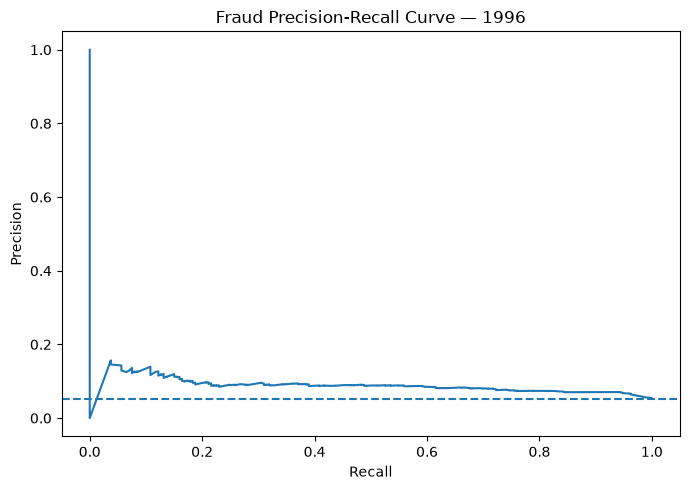

In [24]:
precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_proba
    )
)


plt.figure(
    figsize=(7, 5)
)

plt.plot(
    recall_curve,
    precision_curve
)

plt.axhline(
    y=test_prevalence,
    linestyle="--"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Fraud Precision-Recall Curve — 1996"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "fraud_final_precision_recall_curve.png",
    dpi=150
)

plt.show()

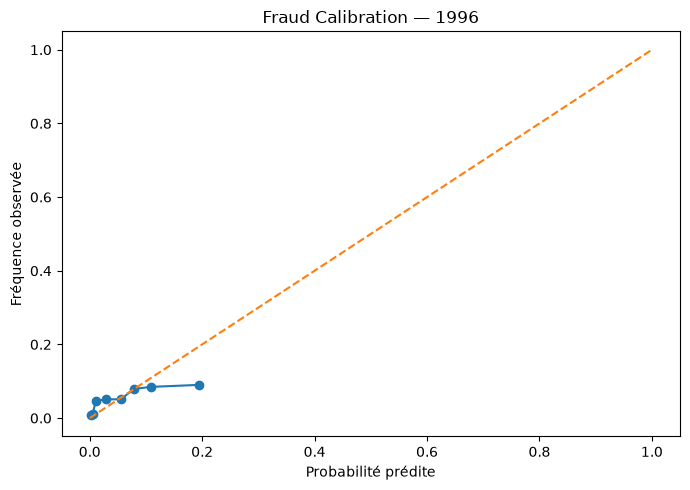

In [25]:
prob_true, prob_pred = (
    calibration_curve(
        y_test,
        test_proba,
        n_bins=8,
        strategy="quantile"
    )
)


plt.figure(
    figsize=(7, 5)
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Probabilité prédite"
)

plt.ylabel(
    "Fréquence observée"
)

plt.title(
    "Fraud Calibration — 1996"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "fraud_final_calibration_curve.png",
    dpi=150
)

plt.show()

In [26]:
fraud_predictions = pd.DataFrame({
    "PolicyNumber":
        test_1996[
            "PolicyNumber"
        ].values,

    "actual":
        y_test.values,

    "probability":
        test_proba,

    "prediction":
        test_pred
})

In [27]:
fraud_predictions[
    "risk_decile"
] = pd.qcut(
    fraud_predictions[
        "probability"
    ],
    q=10,
    labels=False,
    duplicates="drop"
)

In [28]:
decile_analysis = (
    fraud_predictions
    .groupby(
        "risk_decile"
    )
    .agg(
        dossiers=(
            "PolicyNumber",
            "size"
        ),

        frauds=(
            "actual",
            "sum"
        ),

        observed_fraud_rate=(
            "actual",
            "mean"
        ),

        mean_predicted_probability=(
            "probability",
            "mean"
        )
    )
)

In [29]:
decile_analysis[
    "lift_vs_portfolio"
] = (
    decile_analysis[
        "observed_fraud_rate"
    ]
    /
    test_prevalence
)


decile_analysis

,dossiers,frauds,observed_fraud_rate,mean_predicted_probability,lift_vs_portfolio
risk_decile,,,,,
0,792,7,0.008838,0.002440,0.169423
1,92,1,0.010870,0.003490,0.208359
2,344,4,0.011628,0.007441,0.222896
3,424,24,0.056604,0.014242,1.085039
4,402,23,0.057214,0.032005,1.096735
5,397,21,0.052897,0.052376,1.013978
6,424,26,0.061321,0.070727,1.175458
7,391,31,0.079284,0.090655,1.519794
8,409,37,0.090465,0.122900,1.734116


In [30]:
highest_decile = (
    decile_analysis
    .iloc[-1]
)


top_decile_fraud_rate = float(
    highest_decile[
        "observed_fraud_rate"
    ]
)


top_decile_lift = (
    top_decile_fraud_rate
    /
    test_prevalence
)


top_decile_fraud_share = (
    highest_decile[
        "frauds"
    ]
    /
    y_test.sum()
)


print(
    "Portfolio fraud rate :",
    test_prevalence
)

print(
    "Top decile fraud rate :",
    top_decile_fraud_rate
)

print(
    "Top decile lift :",
    top_decile_lift
)

print(
    "Top decile fraud share :",
    top_decile_fraud_share
)

Portfolio fraud rate : 0.05216752387950037
Top decile fraud rate : 0.09558823529411764
Top decile lift : 1.8323322286661141
Top decile fraud share : 0.18309859154929578


In [31]:
validation_reference = {
    "pr_auc":
        0.09038410368422278,

    "roc_auc":
        0.6710019862955114,

    "brier":
        0.05381599102173139,

    "log_loss":
        0.2104749309760136,

    "precision":
        0.09698375870069606,

    "recall":
        0.6943521594684385,

    "f1":
        0.17019543973941367
}

In [32]:
validation_vs_test = pd.DataFrame([
    {
        "metric": "PR-AUC",
        "validation_1995": validation_reference["pr_auc"],
        "test_1996": test_pr_auc
    },
    {
        "metric": "ROC-AUC",
        "validation_1995": validation_reference["roc_auc"],
        "test_1996": test_roc_auc
    },
    {
        "metric": "Brier",
        "validation_1995": validation_reference["brier"],
        "test_1996": test_brier
    },
    {
        "metric": "Log Loss",
        "validation_1995": validation_reference["log_loss"],
        "test_1996": test_log_loss
    },
    {
        "metric": "Precision",
        "validation_1995": validation_reference["precision"],
        "test_1996": test_precision
    },
    {
        "metric": "Recall",
        "validation_1995": validation_reference["recall"],
        "test_1996": test_recall
    },
    {
        "metric": "F1",
        "validation_1995": validation_reference["f1"],
        "test_1996": test_f1
    }
])


validation_vs_test

,metric,validation_1995,test_1996
0,PR-AUC,0.090384,0.091127
1,ROC-AUC,0.671002,0.674790
2,Brier,0.053816,0.051080
3,Log Loss,0.210475,0.206180
4,Precision,0.096984,0.088710
5,Recall,0.694352,0.464789
6,F1,0.170195,0.148984


In [33]:
fraud_predictions.to_csv(
    REPORT_DIR
    / "fraud_final_predictions_1996.csv",
    index=False
)


decile_analysis.to_csv(
    REPORT_DIR
    / "fraud_decile_analysis_1996.csv"
)


validation_vs_test.to_csv(
    REPORT_DIR
    / "fraud_validation_vs_test.csv",
    index=False
)

In [34]:
MODEL_PATH = (
    ARTIFACTS_DIR
    / "fraud_random_forest_isotonic.joblib"
)


joblib.dump(
    final_fraud_model,
    MODEL_PATH
)


print(
    MODEL_PATH
)

c:\Users\user\ai-business-advisor-v2\data-science\artifacts\fraud_random_forest_isotonic.joblib


In [35]:
loaded_model = joblib.load(
    MODEL_PATH
)


sample_X = (
    X_test
    .head(10)
    .copy()
)


original_proba = (
    final_fraud_model
    .predict_proba(
        sample_X
    )[:, 1]
)


reloaded_proba = (
    loaded_model
    .predict_proba(
        sample_X
    )[:, 1]
)


np.testing.assert_allclose(
    original_proba,
    reloaded_proba
)


print(
    "Reload test : OK"
)

Reload test : OK


In [36]:
candidate_config[
    "test_used"
] = True

candidate_config[
    "test_evaluation_completed"
] = True

In [37]:
with open(
    METADATA_DIR / "fraud_candidate.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        candidate_config,
        f,
        indent=4,
        ensure_ascii=False
    )

In [38]:
print(
    "=" * 80
)

print(
    "FRAUD — FINAL TEMPORAL TEST RESULTS"
)

print(
    "=" * 80
)


print(
    "\n=== DATA ==="
)

print(
    "1994 training observations :",
    len(train_1994)
)

print(
    "1994 frauds :",
    y_train.sum()
)

print(
    "1996 test observations :",
    len(test_1996)
)

print(
    "1996 frauds :",
    y_test.sum()
)

print(
    "1996 fraud prevalence :",
    test_prevalence
)


print(
    "\n=== FINAL MODEL ==="
)

print(
    "Random Forest + Isotonic"
)

print(
    "Threshold :",
    TECHNICAL_THRESHOLD
)

for key, value in (
    rf_parameters.items()
):

    print(
        key,
        "=",
        value
    )


print(
    "\n=== PROBABILITY METRICS ==="
)

print(
    "PR-AUC :",
    test_pr_auc
)

print(
    "ROC-AUC :",
    test_roc_auc
)

print(
    "Brier :",
    test_brier
)

print(
    "Log Loss :",
    test_log_loss
)

print(
    "PR-AUC lift vs prevalence :",
    pr_auc_lift
)


print(
    "\n=== THRESHOLD METRICS ==="
)

print(
    "Precision :",
    test_precision
)

print(
    "Recall :",
    test_recall
)

print(
    "F1 :",
    test_f1
)

print(
    "Flagged dossiers :",
    flagged_count
)

print(
    "Flagged rate :",
    flagged_rate
)


print(
    "\n=== CONFUSION MATRIX ==="
)

print(
    test_cm
)

print(
    "TN =",
    tn
)

print(
    "FP =",
    fp
)

print(
    "FN =",
    fn
)

print(
    "TP =",
    tp
)


print(
    "\n=== RISK SEGMENTATION ==="
)

print(
    "Portfolio fraud rate :",
    test_prevalence
)

print(
    "Top decile fraud rate :",
    top_decile_fraud_rate
)

print(
    "Top decile lift :",
    top_decile_lift
)

print(
    "Top decile fraud share :",
    top_decile_fraud_share
)


print(
    "\n=== DECILE ANALYSIS ==="
)

print(
    decile_analysis
    .round(6)
    .to_string()
)


print(
    "\n=== VALIDATION 1995 VS TEST 1996 ==="
)

print(
    validation_vs_test
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== ARTIFACT ==="
)

print(
    MODEL_PATH
)

print(
    "Reload test : OK"
)


print(
    "\n1996 TEST UTILISÉ : OUI"
)

print(
    "RETUNING APRÈS 1996 : NON"
)


print(
    "=" * 80
)

FRAUD — FINAL TEMPORAL TEST RESULTS

=== DATA ===
1994 training observations : 6142
1994 frauds : 409
1996 test observations : 4083
1996 frauds : 213
1996 fraud prevalence : 0.05216752387950037

=== FINAL MODEL ===
Random Forest + Isotonic
Threshold : 0.08585764735167348
n_estimators = 800
min_samples_split = 5
min_samples_leaf = 10
max_features = log2
max_depth = 16
class_weight = None

=== PROBABILITY METRICS ===
PR-AUC : 0.09112694706957003
ROC-AUC : 0.6747898242166175
Brier : 0.05107961040941232
Log Loss : 0.2061801467721034
PR-AUC lift vs prevalence : 1.7468137318547157

=== THRESHOLD METRICS ===
Precision : 0.08870967741935484
Recall : 0.4647887323943662
F1 : 0.1489841986455982
Flagged dossiers : 1116
Flagged rate : 0.2733284349742836

=== CONFUSION MATRIX ===
[[2853 1017]
 [ 114   99]]
TN = 2853
FP = 1017
FN = 114
TP = 99

=== RISK SEGMENTATION ===
Portfolio fraud rate : 0.05216752387950037
Top decile fraud rate : 0.09558823529411764
Top decile lift : 1.8323322286661141
Top deci

## Évaluation finale du modèle de détection de fraude

Le modèle retenu est un Random Forest calibré par méthode isotonic.

Le protocole expérimental est temporel :

- 1994 : apprentissage et tuning interne ;
- 1995 : validation temporelle et sélection du seuil ;
- 1996 : évaluation finale.

Les observations et labels de 1996 n'ont pas été utilisés pour
l'apprentissage, le tuning, la sélection de la calibration ou
le choix du seuil.

La prévalence globale de 1996 avait toutefois été examinée
préalablement à titre descriptif.

### Données du test

L'année 1996 contient :

- 4 083 dossiers ;
- 213 fraudes ;
- un taux de fraude de 5,22 %.

### Performances probabilistes

Le modèle obtient :

| Métrique | Résultat |
|---|---:|
| PR-AUC | 0.09113 |
| ROC-AUC | 0.67479 |
| Brier Score | 0.05108 |
| Log Loss | 0.20618 |

La PR-AUC est environ 1,75 fois supérieure à la prévalence
de la fraude dans le jeu de test.

Le modèle possède donc une capacité réelle mais modérée
à prioriser les dossiers frauduleux.

### Stabilité temporelle

Sur la validation 1995 :

- PR-AUC = 0.09038 ;
- ROC-AUC = 0.67100.

Sur le test 1996 :

- PR-AUC = 0.09113 ;
- ROC-AUC = 0.67479.

La capacité de classement du modèle reste donc relativement
stable entre les deux années.

Cette stabilité est particulièrement importante dans le cadre
d'une évaluation temporelle.

### Résultats au seuil technique

Le seuil sélectionné sur l'année 1995 est :

0.08586

Sur 1996, il produit :

- Precision = 8,87 % ;
- Recall = 46,48 % ;
- F1-score = 14,90 %.

La matrice de confusion est :

| | Prédit non fraude | Prédit fraude |
|---|---:|---:|
| Réel non fraude | 2 853 | 1 017 |
| Réel fraude | 114 | 99 |

Le modèle détecte donc 99 fraudes sur 213.

Il signale 1 116 dossiers, soit environ 27,33 % des dossiers
de l'année 1996.

### Stabilité du seuil

Le Recall était de 69,44 % sur la validation 1995 mais descend
à 46,48 % sur 1996.

En revanche, les métriques de ranking PR-AUC et ROC-AUC restent stables.

Cette différence montre que la capacité du modèle à classer les dossiers
se généralise mieux que la règle de classification basée sur un seuil fixe.

Dans un système réel, le seuil devrait donc faire l'objet d'un suivi
opérationnel et être défini en fonction du coût des investigations
et du coût des fraudes non détectées.

### Segmentation du risque

Le taux de fraude global du portefeuille 1996 est de 5,22 %.

Pour le groupe de dossiers ayant les scores les plus élevés,
le taux observé atteint environ :

9,56 %.

Le lift du groupe supérieur est donc :

1,83.

Ce groupe concentre environ :

18,31 % des fraudes observées.

Cette analyse confirme que le modèle peut être utilisé comme outil
de priorisation des dossiers à examiner.

### Calibration

Bien que les métriques probabilistes globales restent stables,
la calibration n'est pas parfaite dans tous les segments.

Certains groupes intermédiaires présentent une sous-estimation
du taux de fraude, tandis que le groupe présentant les scores
les plus élevés tend à être surestimé.

Le modèle doit donc principalement être interprété comme un système
d'aide à la priorisation et non comme une source de probabilités
individuelles parfaitement calibrées.

### Limites

Les performances de détection restent modestes.

Cette difficulté est cohérente avec :

- le faible nombre de fraudes disponibles ;
- le fort déséquilibre de classes ;
- le caractère temporel de l'évaluation ;
- l'exclusion volontaire de variables dont la disponibilité
  au moment de la prédiction n'était pas suffisamment garantie.

Le modèle ne doit donc pas prendre seul une décision d'accusation
ou de rejet d'un dossier.

Il constitue un outil d'aide permettant de prioriser les dossiers
pour investigation humaine.

In [39]:
fraud_final_metadata = {

    "model_name":
        "fraud_random_forest_isotonic",

    "model_version":
        "1.0.0",

    "task":
        "fraud_classification",

    "target":
        "FraudFound_P",

    "training_year":
        1994,

    "validation_year":
        1995,

    "test_year":
        1996,

    "model":
        "RandomForestClassifier",

    "calibration":
        "isotonic",

    "hyperparameters":
        rf_parameters,

    "technical_threshold":
        float(
            TECHNICAL_THRESHOLD
        ),

    "holdout_metrics": {

        "prevalence":
            float(
                test_prevalence
            ),

        "pr_auc":
            float(
                test_pr_auc
            ),

        "roc_auc":
            float(
                test_roc_auc
            ),

        "brier":
            float(
                test_brier
            ),

        "log_loss":
            float(
                test_log_loss
            ),

        "precision":
            float(
                test_precision
            ),

        "recall":
            float(
                test_recall
            ),

        "f1":
            float(
                test_f1
            ),

        "flagged_rate":
            float(
                flagged_rate
            ),

        "top_decile_lift":
            float(
                top_decile_lift
            ),

        "top_decile_fraud_share":
            float(
                top_decile_fraud_share
            )
    },

    "artifact":
        MODEL_PATH.name,

    "test_used":
        True
}

In [40]:
with open(
    METADATA_DIR
    / "fraud_model_v1.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        fraud_final_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✅ fraud_model_v1.json sauvegardé"
)

✅ fraud_model_v1.json sauvegardé


In [41]:
with open(
    METADATA_DIR
    / "fraud_model_v1.json",
    "r",
    encoding="utf-8"
) as f:

    fraud_metadata_check = json.load(f)


print(
    json.dumps(
        fraud_metadata_check,
        indent=4
    )
)

{
    "model_name": "fraud_random_forest_isotonic",
    "model_version": "1.0.0",
    "task": "fraud_classification",
    "target": "FraudFound_P",
    "training_year": 1994,
    "validation_year": 1995,
    "test_year": 1996,
    "model": "RandomForestClassifier",
    "calibration": "isotonic",
    "hyperparameters": {
        "n_estimators": 800,
        "min_samples_split": 5,
        "min_samples_leaf": 10,
        "max_features": "log2",
        "max_depth": 16,
        "class_weight": null
    },
    "technical_threshold": 0.08585764735167348,
    "holdout_metrics": {
        "prevalence": 0.05216752387950037,
        "pr_auc": 0.09112694706957003,
        "roc_auc": 0.6747898242166175,
        "brier": 0.05107961040941232,
        "log_loss": 0.2061801467721034,
        "precision": 0.08870967741935484,
        "recall": 0.4647887323943662,
        "f1": 0.1489841986455982,
        "flagged_rate": 0.2733284349742836,
        "top_decile_lift": 1.8323322286661141,
        "top_de

In [42]:
import sys

import sklearn
import xgboost
import pandas
import numpy
import joblib
import scipy


print(
    "Python executable :",
    sys.executable
)

print(
    "Python version    :",
    sys.version
)

print(
    "scikit-learn     :",
    sklearn.__version__
)

print(
    "xgboost           :",
    xgboost.__version__
)

print(
    "pandas            :",
    pandas.__version__
)

print(
    "numpy             :",
    numpy.__version__
)

print(
    "joblib            :",
    joblib.__version__
)

print(
    "scipy             :",
    scipy.__version__
)

Python executable : c:\Users\user\ai-business-advisor-v2\.venv\Scripts\python.exe
Python version    : 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
scikit-learn     : 1.9.1
xgboost           : 3.4.1
pandas            : 3.0.6
numpy             : 2.5.3
joblib            : 1.6.0
scipy             : 1.18.1
